# Assignment 1
## Uncertainty and Sentiment in ARK Company Filings
FRE-GY 7871 A, Fall 2026. The analysis follows the current assignment brief. The instructor supplied data acquisition; the analysis additions and AI assistance are disclosed in `AI_USE.md`.

This is a retrospective event study, not an out-of-sample investment strategy. The complete specification and declared sensitivities are in [METHODOLOGY.md](METHODOLOGY.md).

## Reproduction
Run scripts `00` through `03`, then `05_get_price_actions.py` first. The downloads remain local and are excluded from Git. This notebook executes the analysis from those inputs, including text parsing, share recovery, exact-sample TF-IDF, all regressions and figures. A cached text matrix accelerates reruns; `build_text_data(force=True)` rebuilds it from the original HTML.

In [1]:
from pathlib import Path
import os, sys, runpy, json, subprocess
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
assert (ROOT/'src/config.py').exists(), 'Run the notebook from the repository root.'
os.environ['MPLCONFIGDIR']=str(ROOT/'outputs/mpl_cache')
sys.path.insert(0,str(ROOT))
RESULTS=ROOT/'outputs/analysis'
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',30)
pd.set_option('display.float_format',lambda x:f'{x:.4f}')


## Numerical and timing tests
The tests cover the paper's weighting formula, same-corpus IDF, early closes, missing returns, compounding, split units, inline text, shell checkboxes, common-share classes, and redundant fixed effects.

In [2]:
r=subprocess.run([sys.executable,'-m','pytest','tests','-q'],cwd=ROOT,capture_output=True,text=True)
print(r.stdout)
assert r.returncode==0,r.stderr

..........                                                               [100%]
10 passed in 1.34s



## Run the complete analysis
The initial specification was defined independently of significance. The student subsequently requested removal of the optional $3 price cutoff; all results below use that amended sample, retaining low-priced stocks. Returns and volatility have separate sample waterfalls. Within each specification IDF is estimated on exactly its regression documents. Before/after pre-volatility-control pairs share the same sample.

In [3]:
analysis=runpy.run_path(str(ROOT/'scripts/06_run_analysis.py'),run_name='analysis_module')
summary=analysis['main']()

{
  "core_filings": 1624,
  "core_firms": 91,
  "core_forms": {
    "10-Q": 1228,
    "10-K": 396
  },
  "unique_downloaded_filings": 1682,
  "duplicate_security_records_removed": 20,
  "shell_filings_removed": 58,
  "unknown_shell_status": 0,
  "vol_sample": 1591,
  "return_sample": 1592,
  "shifted_event_days": 921,
  "shares_sources": {
    "cover_xbrl_total": 1080,
    "cover_xbrl_class_sum": 571,
    "cover_sentence": 26,
    "same_accession_instant_fact": 4,
    "unresolved": 1
  },
  "core_unresolved_shares": 15,
  "cover_sentence_recoveries": 26,
  "parser_old_words": 48537683,
  "parser_new_words": 62590430,
  "lexicon_overlap": 40,
  "top30_negative_share": 46.393553691827,
  "top30_uncertainty_share": 90.43154482654644,
  "quarterly_observations": 20,
  "correlations": [
    {
      "form": "10-K",
      "weight": "prop",
      "correlation": 0.7217520986983796
    },
    {
      "form": "10-K",
      "weight": "tfidf",
      "correlation": 0.8379485958917098
    },
    {
  

## Table 1 — Sample filters
The universe table counts securities/issuers. The filing table counts unique documents; the raw 1,702 ticker-filing rows contain 20 duplicate Alphabet reports. Unknown SEC mappings are reported as unresolved, not presumed to be private firms. Shell status is assessed at the filing date.

In [4]:
display(pd.read_csv(RESULTS/'table1_universe.csv'))
display(pd.read_csv(RESULTS/'table1_filings.csv'))

,filter,remaining,removed
0,Unique cleaned securities in frozen snapshot,124,0
1,SEC ticker-to-CIK mapping found,117,7
2,At least one 2021-2025 10-K/10-Q,93,24
3,Distinct issuers after multi-class consolidation,92,1


,branch,filter,removed,remaining,firms
0,text,Starting unique filings,0,1682,92
1,text,Valid acceptance timestamp,0,1682,92
2,text,"At least 2,000 narrative words",0,1682,92
3,text,Exclude explicitly identified shell companies,58,1624,91
4,volatility,Starting unique filings,0,1624,91
5,volatility,Complete 63-day pre-filing returns,32,1592,90
6,volatility,Dated instantaneous common shares and positive...,0,1592,90
7,volatility,Complete positive pre-filing turnover,0,1592,90
8,volatility,Complete 63-day post-filing returns,1,1591,90
9,return,Starting unique filings,0,1624,91


## Measures
Negative language and uncertainty remain separate. A proportional score is category occurrences divided by all tokens. Equation (1) is

$$w_{ij}=\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln(N/df_i),\quad tf_{ij}>0,$$

and zero otherwise, with $a_j=L_j/U_j$, the mean token frequency across all distinct document terms. The category score sums its term weights. Natural logarithms and no smoothing are used. The assignment's nonzero Negative flags include ten removed terms; active-only Negative is a sensitivity.

## Table 2 — Descriptive statistics
Proportional measures in this table are expressed as percentages of all words. TF-IDF scores are sums of weights. Annual and quarterly filings are shown separately.

In [5]:
display(pd.read_csv(RESULTS/'table2.csv'))
display(pd.read_csv(RESULTS/'tone_correlations.csv'))
print('Dictionary overlap:',summary['lexicon_overlap'],'words')

,form,measure,n,mean,sd,p25,median,p75
0,10-K,negative_prop,396,2.3472,0.4062,2.0844,2.3608,2.6202
1,10-K,negative_tfidf,396,163.6839,54.4804,122.1918,155.0447,204.9151
2,10-K,uncertainty_prop,396,1.9472,0.2398,1.8026,1.9690,2.1185
3,10-K,uncertainty_tfidf,396,26.6429,8.1196,21.0620,25.5421,31.2009
4,10-Q,negative_prop,1228,2.1332,0.9479,1.2848,1.9520,3.0204
5,10-Q,negative_tfidf,1228,80.2967,66.2437,24.0206,56.2435,131.1088
6,10-Q,uncertainty_prop,1228,1.8285,0.5870,1.3271,1.6686,2.4192
7,10-Q,uncertainty_tfidf,1228,13.5046,7.2711,7.7880,11.9092,18.7195


,form,weight,correlation
0,10-K,prop,0.7218
1,10-K,tfidf,0.8379
2,10-Q,prop,0.8506
3,10-Q,tfidf,0.9206


Dictionary overlap: 40 words


## Table 3 — Thirty most common words per list
Each share uses all occurrences on its own category list as the denominator. The lists' overlap and correlated topics mean their scores are not statistically independent.

In [6]:
t3=pd.read_csv(RESULTS/'table3.csv')
for category in ['Negative','Uncertainty']:
    display(Markdown('### '+category))
    display(t3.loc[t3.category.eq(category)].reset_index(drop=True))

### Negative

,category,rank,word,count,share_pct
0,Negative,1,LOSS,77905,5.1245
1,Negative,2,ADVERSELY,62801,4.1310
2,Negative,3,LOSSES,47263,3.1089
3,Negative,4,CLAIMS,45110,2.9673
4,Negative,5,ADVERSE,42122,2.7707
5,Negative,6,AGAINST,36255,2.3848
6,Negative,7,UNABLE,29862,1.9643
7,Negative,8,LITIGATION,29647,1.9501
8,Negative,9,HARM,28385,1.8671
9,Negative,10,FAILURE,27561,1.8129


### Uncertainty

,category,rank,word,count,share_pct
0,Uncertainty,1,MAY,439120,35.2152
1,Uncertainty,2,COULD,231154,18.5374
2,Uncertainty,3,RISK,62055,4.9765
3,Uncertainty,4,RISKS,55812,4.4758
4,Uncertainty,5,BELIEVE,36518,2.9286
5,Uncertainty,6,APPROXIMATELY,31896,2.5579
6,Uncertainty,7,ASSUMPTIONS,23943,1.9201
7,Uncertainty,8,INTANGIBLE,20499,1.6439
8,Uncertainty,9,POSSIBLE,15673,1.2569
9,Uncertainty,10,UNCERTAINTIES,14415,1.1560


## Figure 1 — Quarterly tone and VIX
Average within issuer/form/filing quarter before averaging across issuers. Separate 10-K and 10-Q to expose form composition. VIX is quarterly mean market uncertainty on the right axis, not a substitute for company-level realized volatility.

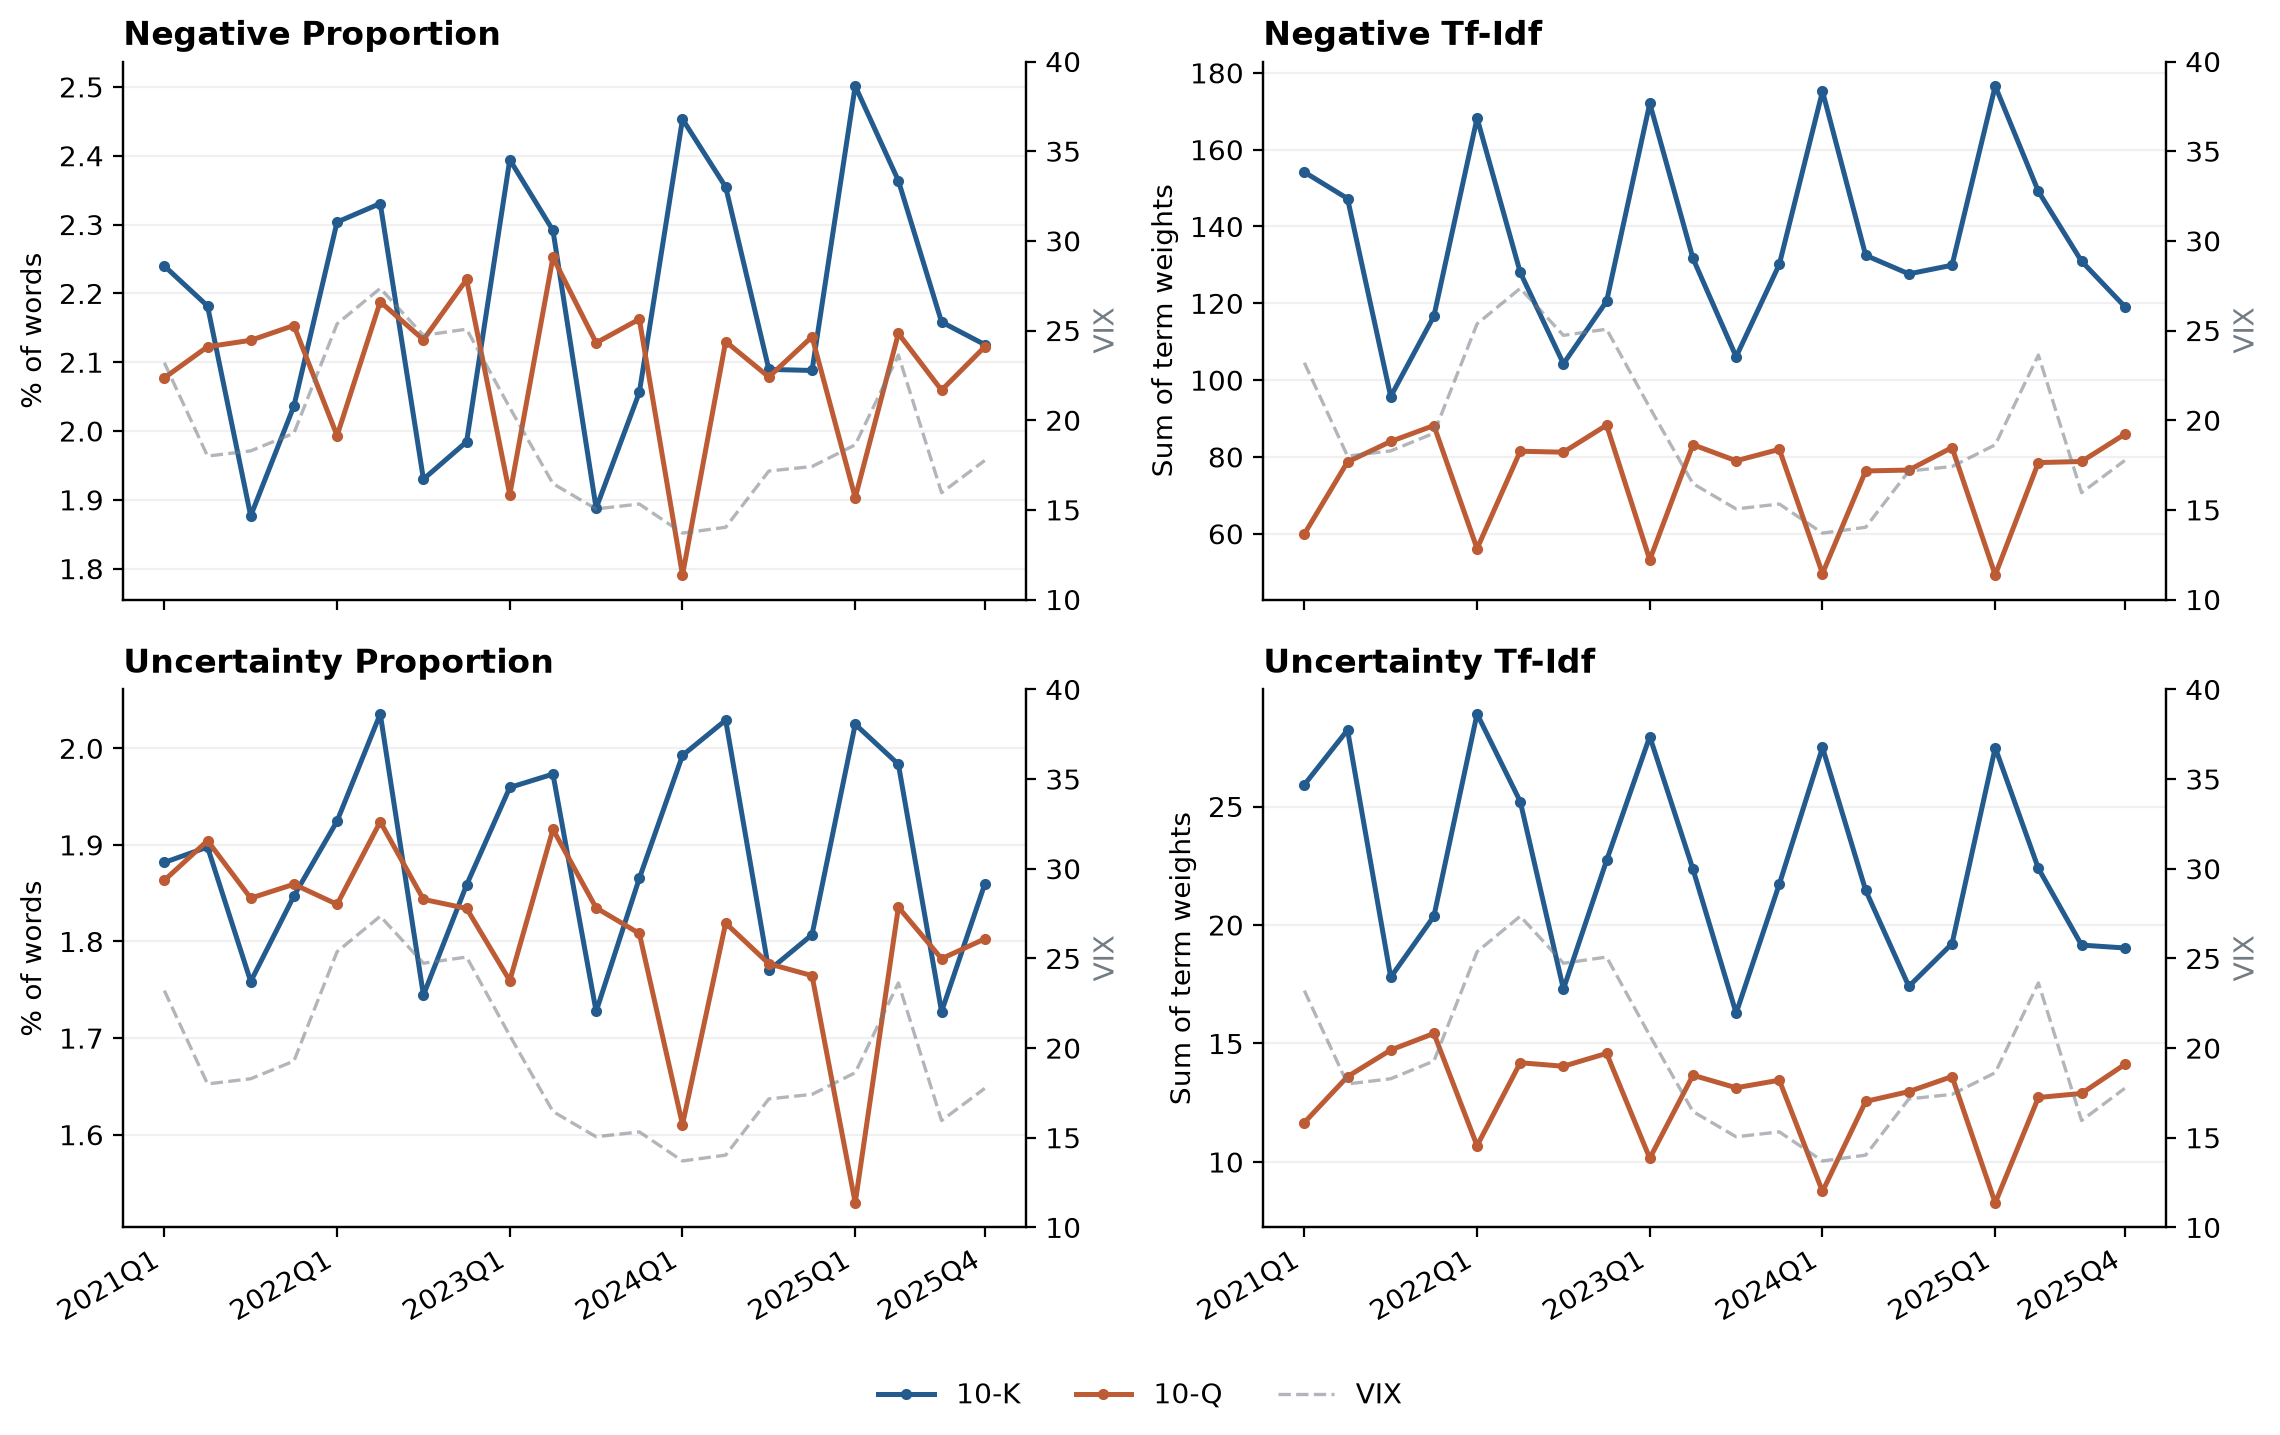

,form,quarter,negative_prop,negative_tfidf,uncertainty_prop,uncertainty_tfidf
0,10-K,2021Q1,0.0224,154.1622,0.0188,25.9201
1,10-K,2021Q2,0.0218,147.2740,0.0190,28.2276
2,10-K,2021Q3,0.0188,95.7287,0.0176,17.7963
3,10-K,2021Q4,0.0204,116.6612,0.0185,20.3679
4,10-K,2022Q1,0.0230,168.2110,0.0192,28.9086
5,10-K,2022Q2,0.0233,128.0380,0.0204,25.2091
6,10-K,2022Q3,0.0193,104.2649,0.0174,17.2953
7,10-K,2022Q4,0.0198,120.5289,0.0186,22.7240
8,10-K,2023Q1,0.0239,172.0514,0.0196,27.9515
9,10-K,2023Q2,0.0229,131.6858,0.0197,22.3545


In [7]:
display(Image(filename=str(RESULTS/'figure1.png')))
display(pd.read_csv(RESULTS/'quarterly_tone.csv'))

## Table 4 — Trend tests
The primary trend test includes issuer and quarter-of-year effects with issuer-clustered SEs. Aggregate OLS and Newey-West (four lags, finite-sample correction) t statistics are both reported. Each slope is in SDs per quarter. Holm correction covers the four category-by-form within-issuer tests separately for each weighting scheme.

In [8]:
t4=pd.read_csv(RESULTS/'table4.csv')
display(t4[['form','measure','aggregate_beta','aggregate_ols_t','aggregate_hac_t','within_beta','within_se','within_p','within_holm_p','within_n','firms']])

,form,measure,aggregate_beta,aggregate_ols_t,aggregate_hac_t,within_beta,within_se,within_p,within_holm_p,within_n,firms
0,10-K,negative_prop,0.0318,6.5325,9.4962,0.0345,0.0047,0.0000,0.0000,392,83
1,10-K,negative_tfidf,0.0176,2.8519,4.7340,0.0133,0.0042,0.0022,0.0067,392,83
2,10-K,uncertainty_prop,0.0119,1.8260,1.7286,0.0249,0.0049,0.0000,0.0000,392,83
3,10-K,uncertainty_tfidf,-0.0124,-1.4374,-2.2295,-0.0077,0.0043,0.0769,0.1539,392,83
4,10-Q,negative_prop,-0.0060,-2.5706,-3.3518,-0.0042,0.0043,0.3325,0.3325,1224,90
5,10-Q,negative_tfidf,-0.0062,-4.1642,-4.0618,-0.0072,0.0045,0.1129,0.1539,1224,90
6,10-Q,uncertainty_prop,-0.0161,-4.3015,-4.5183,-0.0109,0.0046,0.0192,0.0384,1224,90
7,10-Q,uncertainty_tfidf,-0.0179,-6.2779,-6.1633,-0.0181,0.0048,0.0003,0.0014,1224,90


## Table 5 — Uncertainty and next-quarter volatility
The outcome is log annualized volatility on trading days [4,66]. Pre-volatility uses [-63,-1]. Models include log size, log turnover, prior return, form, industry and calendar-quarter effects. The paired models add only log pre-volatility. The score is standardized within the same complete-case corpus, so the coefficient change is not a change in sample composition.

In [9]:
t5=pd.read_csv(RESULTS/'table5.csv')
display(t5[['measure','pre_vol_control','beta','se','t','p','holm_p','ci_low','ci_high','n','firms','corpus']])
assert t5.groupby('measure').corpus.nunique().eq(1).all()

,measure,pre_vol_control,beta,se,t,p,holm_p,ci_low,ci_high,n,firms,corpus
0,uncertainty_prop,False,0.0334,0.0168,1.9851,0.0502,NaN,-0.0000,0.0669,1591,90,9255c7cfd732c13e
1,uncertainty_prop,True,0.0174,0.0086,2.0298,0.0454,0.1361,0.0004,0.0344,1591,90,9255c7cfd732c13e
2,uncertainty_tfidf,False,0.0604,0.0238,2.5446,0.0127,NaN,0.0132,0.1076,1591,90,9255c7cfd732c13e
3,uncertainty_tfidf,True,0.0264,0.0120,2.2095,0.0297,0.1188,0.0027,0.0502,1591,90,9255c7cfd732c13e


## Table 6 — Sentiment and filing-period excess returns
The outcome is stock minus SPY buy-and-hold return over [0,3], in percentage points. Controls include prior volatility and those used above. The minimum detectable effect is an approximate 80%-power precision diagnostic, not observed power.

In [10]:
t6=pd.read_csv(RESULTS/'table6.csv')
display(t6[['measure','beta','se','t','p','holm_p','ci_low','ci_high','mde80','n','firms']])
c=pd.read_csv(RESULTS/'all_regression_coefficients.csv')
display(c.loc[c.model.isin(t6.model)&c.term.isin(['tone_z','log_market_value','log_turnover','pre_return','log_pre_vol'])])

,measure,beta,se,t,p,holm_p,ci_low,ci_high,mde80,n,firms
0,negative_prop,-0.4598,0.3244,-1.4175,0.1598,0.2951,-1.1043,0.1847,0.9175,1592,90
1,negative_tfidf,-0.6703,0.4588,-1.4609,0.1476,0.2951,-1.5819,0.2413,1.2977,1592,90


,model,term,beta,se,t,p,ci_low,ci_high
1877,return_pooled_negative_prop_pre1,tone_z,-0.4598,0.3244,-1.4175,0.1598,-1.1043,0.1847
1878,return_pooled_negative_prop_pre1,log_market_value,-0.4341,0.3096,-1.4020,0.1644,-1.0493,0.1811
1879,return_pooled_negative_prop_pre1,log_turnover,0.6591,0.5394,1.2218,0.2250,-0.4128,1.7310
1880,return_pooled_negative_prop_pre1,pre_return,-0.4832,1.5865,-0.3046,0.7614,-3.6355,2.6691
1881,return_pooled_negative_prop_pre1,log_pre_vol,-1.9502,1.2022,-1.6222,0.1083,-4.3389,0.4385
1917,return_pooled_negative_tfidf_pre1,tone_z,-0.6703,0.4588,-1.4609,0.1476,-1.5819,0.2413
1918,return_pooled_negative_tfidf_pre1,log_market_value,-0.4668,0.3146,-1.4841,0.1413,-1.0919,0.1582
1919,return_pooled_negative_tfidf_pre1,log_turnover,0.6433,0.5427,1.1854,0.2390,-0.4350,1.7216
1920,return_pooled_negative_tfidf_pre1,pre_return,-0.4694,1.5817,-0.2968,0.7673,-3.6123,2.6735
1921,return_pooled_negative_tfidf_pre1,log_pre_vol,-1.9149,1.2191,-1.5707,0.1198,-4.3372,0.5074


## All declared outcome sensitivities
Form-specific samples re-estimate IDF. Other checks replace industry effects with issuer effects, use two-way clustering, change the return benchmark to ARKK, or remove retired Negative terms. Negative nuisance variances in the two-way covariance are disclosed; they are not clipped. There are only 20 time clusters, so those sensitivities also need caution.

In [11]:
models=pd.read_csv(RESULTS/'all_outcome_models.csv')
display(models[['outcome','variant','measure','pre_vol_control','beta','se','p','n','corpus','negative_variance_terms']])

,outcome,variant,measure,pre_vol_control,beta,se,p,n,corpus,negative_variance_terms
0,volatility,pooled,uncertainty_prop,False,0.0334,0.0168,0.0502,1591,9255c7cfd732c13e,NaN
1,volatility,pooled,uncertainty_prop,True,0.0174,0.0086,0.0454,1591,9255c7cfd732c13e,NaN
2,volatility,pooled,uncertainty_tfidf,False,0.0604,0.0238,0.0127,1591,9255c7cfd732c13e,NaN
3,volatility,pooled,uncertainty_tfidf,True,0.0264,0.0120,0.0297,1591,9255c7cfd732c13e,NaN
4,volatility,firm_FE,uncertainty_prop,False,-0.0073,0.0107,0.4992,1591,9255c7cfd732c13e,NaN
5,volatility,firm_FE,uncertainty_prop,True,-0.0092,0.0101,0.3675,1591,9255c7cfd732c13e,NaN
6,volatility,firm_FE,uncertainty_tfidf,False,-0.0027,0.0127,0.8305,1591,9255c7cfd732c13e,NaN
7,volatility,firm_FE,uncertainty_tfidf,True,-0.0057,0.0116,0.6221,1591,9255c7cfd732c13e,NaN
8,volatility,two_way,uncertainty_prop,False,0.0334,0.0165,0.0574,1591,9255c7cfd732c13e,C(quarter)[T.2021Q2]|C(quarter)[T.2021Q3]|C(qu...
9,volatility,two_way,uncertainty_prop,True,0.0174,0.0077,0.0351,1591,9255c7cfd732c13e,C(quarter)[T.2021Q4]|C(quarter)[T.2024Q1]|C(qu...


## Interpretation and limitations
Annual-report negative language rises within issuers under both weighting schemes; uncertainty trends differ by form and weight. The pre-volatility control attenuates the uncertainty coefficient, so much of the association reflects existing volatility. Controlled associations are modest and less compelling after family adjustment. Replacing industry effects with issuer effects makes both uncertainty coefficients negative and insignificant, so a robust within-issuer predictive relationship is not established. The four-day return test is imprecise. These are different tests with different evidence; a blanket claim that the sample is too small is not warranted.

The 2026 holdings snapshot creates survivorship/selection bias. It does not reveal former holdings that disappeared. Correct acceptance times and contemporaneous share counts do not cure that selection. Further limits include full-corpus scoring, 20 aggregate quarters, daily timing, overlapping windows, and multi-class valuation approximations. The next improvement is a historical holdings universe followed by a held-out forecasting evaluation.

See the short PDF report for the test-by-test discussion and `AI_USE.md` for the authorship disclosure.